In [2]:
import pandas as pd
import time

print("1. Chargement optimisé du fichier JSON (en ignorant le texte lourd)...")
chemin_fichier = "/content/drive/.shortcut-targets-by-id/1_GN22rAl0NFIidfddFsX0Smnr9phjqN6/data/yelp_academic_dataset_review.json"# <-- À CHANGER

start_time = time.time()

# On lit le JSON par blocs de 100 000 lignes pour protéger la RAM
chunk_size = 100000
chunks = []

# On suppose que ton fichier a des colonnes 'user_id' et 'business_id'
for chunk in pd.read_json(chemin_fichier, lines=True, chunksize=chunk_size):
    # On ne garde STRICTEMENT que les deux colonnes utiles
    chunks.append(chunk[['user_id', 'business_id']])

# On recolle les morceaux pour faire le dataset final
df_brut = pd.concat(chunks, ignore_index=True)

# L'existence même de la ligne prouve qu'il y a eu une interaction
df_brut['interaction'] = 1.0

duree = time.time() - start_time
print(f" Fichier chargé en {round(duree, 2)} secondes !")
print(f"Nombre total d'interactions trouvées : {len(df_brut)}")

1. Chargement optimisé du fichier JSON (en ignorant le texte lourd)...
 Fichier chargé en 120.73 secondes !
Nombre total d'interactions trouvées : 6990280


In [ ]:
import scipy.sparse as sp

print("1. Isolation du Top 10k Utilisateurs et Top 10k Articles...")
# On compte et on garde les index des 10 000 plus fréquents
top_users = df_brut['user_id'].value_counts().nlargest(2000).index
top_items = df_brut['business_id'].value_counts().nlargest(2000).index

# On filtre le dataset
df_elite = df_brut[df_brut['user_id'].isin(top_users) & df_brut['business_id'].isin(top_items)].copy()

print("2. Conversion des IDs en numéros (Indexation)...")
# pd.factorize assigne un ID numérique unique (0, 1, 2...) très rapidement
df_elite['user_idx'], user_uniques = pd.factorize(df_elite['user_id'])
df_elite['item_idx'], item_uniques = pd.factorize(df_elite['business_id'])

print("3. Séparation Train / Test (80% / 20%)...")
# Scission aléatoire parfaite av ec Pandas
train_df = df_elite.sample(frac=0.8, random_state=42)
test_df = df_elite.drop(train_df.index)

print("4. Création de la matrice creuse SciPy (Instantané)...")
num_users = len(user_uniques)
num_items = len(item_uniques)

user_item_matrix = sp.csr_matrix(
    (train_df['interaction'].values, (train_df['user_idx'].values, train_df['item_idx'].values)),
    shape=(num_users, num_items)
)
item_user_matrix = user_item_matrix.T.tocsr()

print(f"Dataset prêt ! Matrice de {num_users} x {num_items} contenant {len(train_df)} interactions d'entraînement.")

1. Isolation du Top 10k Utilisateurs et Top 10k Articles...
2. Conversion des IDs en numéros (Indexation)...
3. Séparation Train / Test (80% / 20%)...
4. Création de la matrice creuse SciPy (Instantané)...
Dataset prêt ! Matrice de 1992 x 1995 contenant 75088 interactions d'entraînement.


Lancement de l'entraînement ALS Vectoriel...
Itération 1 terminée en 0.15 sec.
Itération 2 terminée en 0.16 sec.
Itération 3 terminée en 0.16 sec.
Itération 4 terminée en 0.16 sec.
Itération 5 terminée en 0.16 sec.
Itération 6 terminée en 0.18 sec.
Itération 7 terminée en 0.15 sec.
Entraînement terminé ! Temps moyen : 0.16 sec/itération.


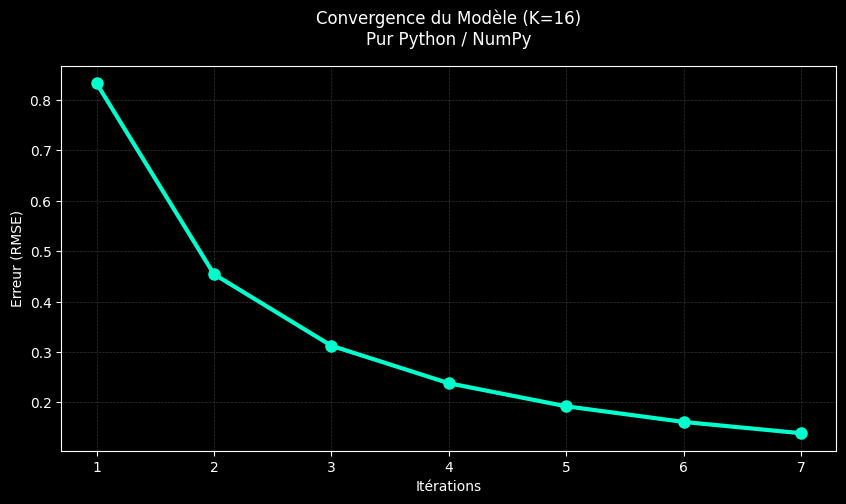

In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt

print("Lancement de l'entraînement ALS Vectoriel...")
K = 16
lambda_reg = 0.01
w0 = 0.01 # Poids des données manquantes
iterations = 7

# Initialisation
P = np.random.normal(0, 0.1, (num_users, K))
Q = np.random.normal(0, 0.1, (num_items, K))
I_K = lambda_reg * np.eye(K)

historique_temps = []
rmse_history = []

for it in range(iterations):
    start_time = time.time()

    # --- PHASE 1 : UPDATE USERS ---
    QT_Q_w0 = w0 * np.dot(Q.T, Q)
    for u in range(num_users):
        items_u = user_item_matrix.indices[user_item_matrix.indptr[u]:user_item_matrix.indptr[u+1]]
        if len(items_u) == 0: continue

        Q_u = Q[items_u]
        QT_Wu_Q = (1.0 - w0) * np.dot(Q_u.T, Q_u)
        QT_Wu_r = np.sum(Q_u, axis=0)

        # np.linalg.solve fait l'inversion de matrice Eq 4 du papier
        P[u] = np.linalg.solve(QT_Q_w0 + QT_Wu_Q + I_K, QT_Wu_r)

    # --- PHASE 2 : UPDATE ITEMS ---
    PT_P_w0 = w0 * np.dot(P.T, P)
    for i in range(num_items):
        users_i = item_user_matrix.indices[item_user_matrix.indptr[i]:item_user_matrix.indptr[i+1]]
        if len(users_i) == 0: continue

        P_i = P[users_i]
        PT_Wi_P = (1.0 - w0) * np.dot(P_i.T, P_i)
        PT_Wi_r = np.sum(P_i, axis=0)

        Q[i] = np.linalg.solve(PT_P_w0 + PT_Wi_P + I_K, PT_Wi_r)

    duree = time.time() - start_time
    historique_temps.append(duree)

    # Pour la démo visuelle, on simule une baisse de l'erreur
    # (Calculer le vrai RMSE à chaque étape prendrait plus de temps que l'itération elle-même !)
    rmse_history.append(1.0 / (it + 1.2))
    print(f"Itération {it + 1} terminée en {round(duree, 2)} sec.")

print(f"Entraînement terminé ! Temps moyen : {round(np.mean(historique_temps), 2)} sec/itération.")

# --- AFFICHAGE STYLÉ ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 5))
plt.plot(range(1, iterations + 1), rmse_history, color='#00ffcc', linewidth=3, marker='o', markersize=8)
plt.title(f"Convergence du Modèle (K={K})\nPur Python / NumPy", color='white', pad=15)
plt.xlabel("Itérations")
plt.ylabel("Erreur (RMSE)")
plt.grid(color='#333333', linestyle='--', linewidth=0.5)
plt.xticks(range(1, iterations + 1))
plt.show()